In [1]:
!pip install rdkit
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 63.7 MB/s eta 0:00:00


In [2]:

# Install dependencies (run once in Colab)
!pip install -q tensorflow pandas scikit-learn matplotlib


In [3]:

import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from tensorflow import keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

SEED = 23
MAX_LEN = 64
EMBED_DIM = 32
GRU_UNITS = 32
DROPOUT = 0.40
LR = 5e-4
BATCH_SIZE = 32
EPOCHS = 40
PATIENCE = 8

def set_seed(seed=SEED):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seed(SEED)


In [4]:

# Load dataset
csv_path = keras.utils.get_file(
    "HIV7.csv",
    "https://raw.githubusercontent.com/McahitKutsal/hivcsv/main/HIV7.csv"
)
df = pd.read_csv(csv_path)
df["smiles"] = df["smiles"].astype(str)
df = df[df["smiles"].str.len() < MAX_LEN].reset_index(drop=True)

print(df.shape)
print(df["HIV_active"].value_counts())
df.head()


158661/158661 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(2394, 4)
HIV_active
0    1412
1     982
Name: count, dtype: int64


,Unnamed: 0,smiles,activity,HIV_active
0,0,CNC(=O)Nc1ccncc1,CI,0
1,1,O=C1NC(O)c2cccc(Cl)c2O1,CI,0
2,2,O=S1(=O)C=Cc2ccccc2CC1,CI,0
3,3,Cc1ccc(OS(=O)(=O)c2ccccc2[N+](=O)[O-])cc1,CM,1
4,4,CN(c1ccccc1)S(=O)(=O)c1cccc([N+](=O)[O-])c1,CM,1


In [5]:

# Vocabulary built from the full dataset for consistent encoding across folds
special_tokens = ["<PAD>", "<UNK>"]
chars = sorted(set("".join(df["smiles"].tolist())))
vocab = special_tokens + chars
char_to_int = {c:i for i,c in enumerate(vocab)}
PAD_IDX = char_to_int["<PAD>"]
UNK_IDX = char_to_int["<UNK>"]
VOCAB_SIZE = len(vocab)

def encode_smiles(smiles_series, max_len=MAX_LEN):
    X = np.full((len(smiles_series), max_len), PAD_IDX, dtype=np.int32)
    for i, sm in enumerate(smiles_series):
        encoded = [char_to_int.get(ch, UNK_IDX) for ch in sm[:max_len]]
        X[i, :len(encoded)] = encoded
    return X

def build_gru_model(input_length=MAX_LEN, vocab_size=VOCAB_SIZE):
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=EMBED_DIM, input_length=input_length, mask_zero=True),
        GRU(GRU_UNITS, return_sequences=False, dropout=DROPOUT, recurrent_dropout=0.15),
        Dropout(DROPOUT),
        Dense(64, activation="relu"),
        Dropout(0.20),
        Dense(1, activation="sigmoid")
    ])
    model.compile(
        optimizer=Adam(learning_rate=LR),
        loss="binary_crossentropy",
        metrics=[keras.metrics.BinaryAccuracy(name="accuracy"), keras.metrics.AUC(name="auc")]
    )
    return model

def summarize_history(history):
    hist = history.history
    return {
        "loss": hist.get("loss", []),
        "val_loss": hist.get("val_loss", []),
        "accuracy": hist.get("accuracy", []),
        "val_accuracy": hist.get("val_accuracy", []),
        "auc": hist.get("auc", []),
        "val_auc": hist.get("val_auc", [])
    }

def find_best_threshold_by_f1(y_true, y_prob):
    thresholds = np.arange(0.10, 0.91, 0.02)
    best_thr = 0.50
    best_f1 = -1.0
    for thr in thresholds:
        y_pred = (y_prob >= thr).astype(int)
        score = f1_score(y_true, y_pred, zero_division=0)
        if score > best_f1:
            best_f1 = score
            best_thr = thr
    return float(best_thr), float(best_f1)


In [6]:

def run_fold(train_df, val_df, test_df, fold_id):
    set_seed(SEED + fold_id)

    X_train = encode_smiles(train_df["smiles"])
    X_val   = encode_smiles(val_df["smiles"])
    X_test  = encode_smiles(test_df["smiles"])

    y_train = train_df["HIV_active"].astype(np.float32).values
    y_val   = val_df["HIV_active"].astype(np.float32).values
    y_test  = test_df["HIV_active"].astype(np.float32).values

    model = build_gru_model()

    early_stop = EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=PATIENCE,
        restore_best_weights=True,
        verbose=1
    )

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stop],
        shuffle=True,
        verbose=0
    )

    val_probs = model.predict(X_val, verbose=0).ravel()
    best_threshold, best_val_f1 = find_best_threshold_by_f1(y_val, val_probs)

    test_probs = model.predict(X_test, verbose=0).ravel()
    y_pred = (test_probs >= best_threshold).astype(int)

    fold_result = {
        "fold": fold_id,
        "test_accuracy": accuracy_score(y_test, y_pred),
        "test_precision": precision_score(y_test, y_pred, zero_division=0),
        "test_recall": recall_score(y_test, y_pred, zero_division=0),
        "test_f1": f1_score(y_test, y_pred, zero_division=0),
        "test_roc_auc": roc_auc_score(y_test, test_probs),
        "best_threshold": best_threshold,
        "val_best_f1": best_val_f1,
        "epochs_ran": len(history.history["loss"])
    }

    return fold_result, summarize_history(history)


In [7]:

all_fold_results = []
all_histories = []

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
X_index = np.arange(len(df))
y = df["HIV_active"].values

for fold_id, (train_idx, temp_idx) in enumerate(skf.split(X_index, y), start=1):
    train_df = df.iloc[train_idx].reset_index(drop=True)
    temp_df = df.iloc[temp_idx].reset_index(drop=True)

    val_idx, test_idx = train_test_split(
        np.arange(len(temp_df)),
        test_size=0.5,
        random_state=SEED + fold_id,
        stratify=temp_df["HIV_active"]
    )

    val_df = temp_df.iloc[val_idx].reset_index(drop=True)
    test_df = temp_df.iloc[test_idx].reset_index(drop=True)

    print(f"\n===== Fold {fold_id} =====")
    print("Train:", len(train_df), "Val:", len(val_df), "Test:", len(test_df))

    fold_result, hist = run_fold(train_df, val_df, test_df, fold_id)
    print(fold_result)
    all_fold_results.append(fold_result)
    all_histories.append(hist)

results_df = pd.DataFrame(all_fold_results)
results_df



===== Fold 1 =====
Train: 1915 Val: 239 Test: 240


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Restoring model weights from the end of the best epoch: 38.
{'fold': 1, 'test_accuracy': 0.9083333333333333, 'test_precision': 0.9871794871794872, 'test_recall': 0.7857142857142857, 'test_f1': 0.875, 'test_roc_auc': np.float64(0.9221040528887612), 'best_threshold': 0.8000000000000002, 'val_best_f1': 0.8488372093023255, 'epochs_ran': 40}

===== Fold 2 =====
Train: 1915 Val: 239 Test: 240


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Restoring model weights from the end of the best epoch: 38.
{'fold': 2, 'test_accuracy': 0.8583333333333333, 'test_precision': 0.8809523809523809, 'test_recall': 0.7551020408163265, 'test_f1': 0.8131868131868132, 'test_roc_auc': np.float64(0.9099597585513078), 'best_threshold': 0.38, 'val_best_f1': 0.8636363636363636, 'epochs_ran': 40}

===== Fold 3 =====
Train: 1915 Val: 239 Test: 240


...

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 36: early stopping
Restoring model weights from the end of the best epoch: 28.
{'fold': 4, 'test_accuracy': 0.8833333333333333, 'test_precision': 0.8585858585858586, 'test_recall': 0.8585858585858586, 'test_f1': 0.8585858585858586, 'test_roc_auc': np.float64(0.9437638799340927), 'best_threshold': 0.24000000000000002, 'val_best_f1': 0.875, 'epochs_ran': 36}

===== Fold 5 =====
Train: 1916 Val: 239 Test: 239


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Restoring model weights from the end of the best epoch: 36.
{'fold': 5, 'test_accuracy': 0.8786610878661087, 'test_precision': 0.8631578947368421, 'test_recall': 0.8367346938775511, 'test_f1': 0.8497409326424871, 'test_roc_auc': np.float64(0.9132291214358084), 'best_threshold': 0.5000000000000001, 'val_best_f1': 0.8852459016393442, 'epochs_ran': 40}


,fold,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,best_threshold,val_best_f1,epochs_ran
0,1,0.908333,0.987179,0.785714,0.875000,0.922104,0.80,0.848837,40
1,2,0.858333,0.880952,0.755102,0.813187,0.909960,0.38,0.863636,40
2,3,0.916667,0.975904,0.818182,0.890110,0.951071,0.46,0.893855,37
3,4,0.883333,0.858586,0.858586,0.858586,0.943764,0.24,0.875000,36
4,5,0.878661,0.863158,0.836735,0.849741,0.913229,0.50,0.885246,40


In [8]:

summary_rows = []
metric_map = {
    "ACCURACY": "test_accuracy",
    "PRECISION": "test_precision",
    "RECALL": "test_recall",
    "F1": "test_f1",
    "ROC_AUC": "test_roc_auc"
}

for metric_name, col in metric_map.items():
    mean = results_df[col].mean()
    std = results_df[col].std(ddof=1)
    var = results_df[col].var(ddof=1)
    summary_rows.append({
        "Metric": metric_name,
        "Mean": mean,
        "Std": std,
        "Variance": var,
        "Formatted": f"{mean:.3f} ± {std:.3f}"
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv("GRU_summary_results.csv", index=False)
results_df.to_csv("GRU_fold_results.csv", index=False)
summary_df


,Metric,Mean,Std,Variance,Formatted
0,ACCURACY,0.889066,0.023551,0.000555,0.889 ± 0.024
1,PRECISION,0.913156,0.063110,0.003983,0.913 ± 0.063
2,RECALL,0.810864,0.041055,0.001686,0.811 ± 0.041
3,F1,0.857325,0.029131,0.000849,0.857 ± 0.029
4,ROC_AUC,0.928026,0.018433,0.000340,0.928 ± 0.018


In [9]:

final_table = pd.DataFrame([{
    "Model": "GRU",
    "Accuracy": summary_df.loc[summary_df["Metric"] == "ACCURACY", "Formatted"].values[0],
    "Precision": summary_df.loc[summary_df["Metric"] == "PRECISION", "Formatted"].values[0],
    "Recall": summary_df.loc[summary_df["Metric"] == "RECALL", "Formatted"].values[0],
    "F1": summary_df.loc[summary_df["Metric"] == "F1", "Formatted"].values[0],
    "ROC-AUC": summary_df.loc[summary_df["Metric"] == "ROC_AUC", "Formatted"].values[0],
}])

final_table.to_csv("GRU_final_table.csv", index=False)
final_table


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,GRU,0.889 ± 0.024,0.913 ± 0.063,0.811 ± 0.041,0.857 ± 0.029,0.928 ± 0.018


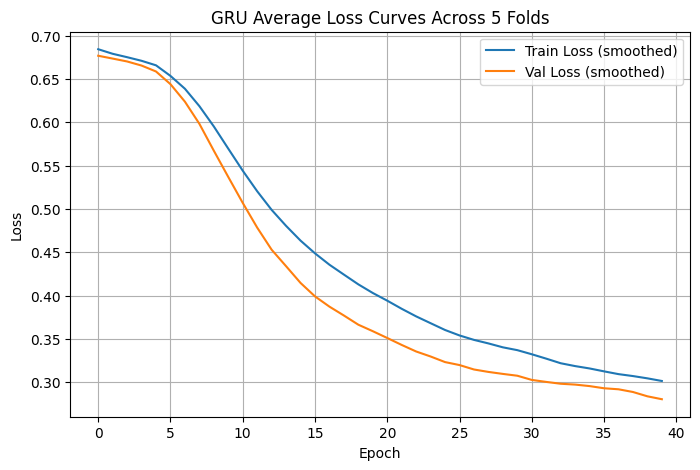

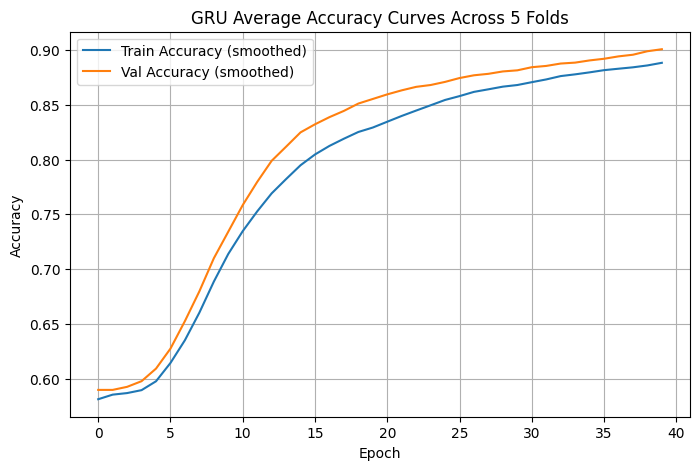

In [10]:

# Average training curves
max_len_hist = max(len(h["loss"]) for h in all_histories)

def pad_hist(hist_list, key):
    arr = []
    for h in hist_list:
        vals = h.get(key, [])
        if len(vals) == 0:
            vals = [0.0] * max_len_hist
        elif len(vals) < max_len_hist:
            vals = vals + [vals[-1]] * (max_len_hist - len(vals))
        arr.append(vals)
    return np.array(arr)

def smooth_curve(values, window=5):
    smoothed = []
    for i in range(len(values)):
        start = max(0, i - window + 1)
        smoothed.append(np.mean(values[start:i+1]))
    return smoothed

loss_arr = pad_hist(all_histories, "loss")
val_loss_arr = pad_hist(all_histories, "val_loss")
acc_arr = pad_hist(all_histories, "accuracy")
val_acc_arr = pad_hist(all_histories, "val_accuracy")

plt.figure(figsize=(8,5))
plt.plot(smooth_curve(loss_arr.mean(axis=0)), label="Train Loss (smoothed)")
plt.plot(smooth_curve(val_loss_arr.mean(axis=0)), label="Val Loss (smoothed)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GRU Average Loss Curves Across 5 Folds")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(smooth_curve(acc_arr.mean(axis=0)), label="Train Accuracy (smoothed)")
plt.plot(smooth_curve(val_acc_arr.mean(axis=0)), label="Val Accuracy (smoothed)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("GRU Average Accuracy Curves Across 5 Folds")
plt.legend()
plt.grid(True)
plt.show()


## GRU docking preparation block

This block is prepared for Colab and designed to run in one pass.

Added workflow:
- RDKit installation cell
- automatically select the best fold
- rebuild the same fold
- retrain the model
- top 10 candidates
- shared column format
- final 2 candidates
- colored 2D molecule drawing
- `.smi` docking file

In [11]:
# Colab RDKit install
import sys, subprocess, pkgutil

if pkgutil.find_loader("rdkit") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "rdkit-pypi"])

from rdkit import Chem
from rdkit.Chem import Descriptors, Draw
from rdkit.Chem import Lipinski as RdLipinski, Crippen, QED

print("RDKit OK")

/tmp/ipykernel_1432/359356715.py:4: DeprecationWarning: 'pkgutil.find_loader' is deprecated and slated for removal in Python 3.14; use importlib.util.find_spec() instead
  if pkgutil.find_loader("rdkit") is None:


RDKit OK


Using fold column: test_roc_auc
Using best fold: 3


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 37: early stopping
Restoring model weights from the end of the best epoch: 29.

GRU TOP 10 CANDIDATES:


,MW,LogP,HBD,HBA,TPSA,RotatableBonds,QED,smiles,fold,y_true,y_pred,y_prob,Lipinski
0,483.565,2.48670,3,6,122.83,10,0.446422,COC(=O)C(C)(C)NC(=O)C(Cc1ccccc1)NC(=O)C(C)(C)N...,3,1.0,1,0.999606,True
1,485.969,3.34072,1,7,148.38,15,0.100467,Cc1cn(C2CC(N=[N+]=[N-])C(COC(=O)CCOCCCCCCCCCl)...,3,1.0,1,0.999604,True
2,445.391,0.56980,3,7,144.99,6,0.551369,O=C(NN1C(=O)C=CC1=O)c1ccccc1Nc1ccccc1C(=O)NN1C...,3,1.0,1,0.999602,True
3,448.961,3.35823,4,6,116.00,3,0.359405,Cc1cc2[nH]c3nc(=N)nc(NS(=O)(=O)c4cc(C)c(Cl)cc4...,3,1.0,1,0.999597,True
4,452.536,4.28309,2,7,98.46,6,0.575830,COc1cc(C2SC(=N)Nc3c2c(C)nn3C(=O)Cc2ccccc2)cc(O...,3,1.0,1,0.999580,True
5,435.521,1.82430,3,6,136.82,8,0.532880,CC(C)(C)OC(=O)CC(NC(=O)OC(C)(C)C)C(=O)NC(Cc1cc...,3,1.0,1,0.999579,True
6,552.354,2.25540,2,4,83.98,7,0.345021,O=C(Nc1cccnc1)c1ccccc1[Se][Se]c1ccccc1C(=O)Nc1...,3,1.0,1,0.999576,False
7,457.286,4.45282,2,5,76.36,3,0.570228,Cc1cc(S(=O)(=O)Nc2nnc3c(Cl)cc(C(F)(F)F)cn23)c(...,3,1.0,1,0.999570,True
8,448.475,1.33480,4,7,135.94,4,0.472793,Cc1ccc(-c2cc(-c3ccccc3)c(C#N)c(=O)n2C2OC(CO)C(...,3,1.0,1,0.999569,True
9,470.503,1.99727,4,9,141.24,5,0.412008,COc1ccc(-c2cc(-c3ccco3)c(C#N)c(=S)n2C2OC(CO)C(...,3,1.0,1,0.999568,True



GRU FINAL 2 CANDIDATES:


,MW,LogP,HBD,HBA,TPSA,RotatableBonds,QED,smiles,fold,y_true,y_pred,y_prob,Lipinski
4,452.536,4.28309,2,7,98.46,6,0.575830,COc1cc(C2SC(=N)Nc3c2c(C)nn3C(=O)Cc2ccccc2)cc(O...,3,1.0,1,0.99958,True
7,457.286,4.45282,2,5,76.36,3,0.570228,Cc1cc(S(=O)(=O)Nc2nnc3c(Cl)cc(C(F)(F)F)cn23)c(...,3,1.0,1,0.99957,True



Saved: GRU_top_10_candidates.csv
Saved: GRU_final_2_candidates.csv
Saved: GRU_docking_input.smi


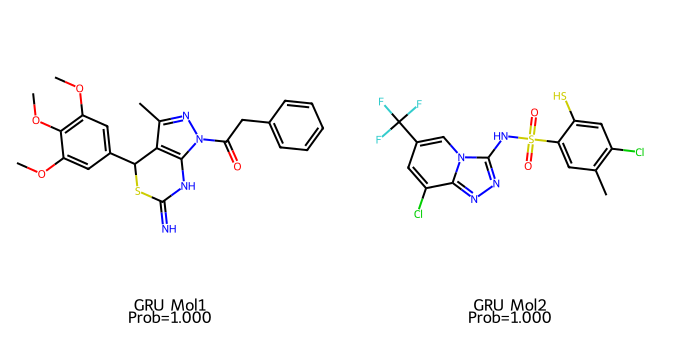

In [12]:
# ================================
# GRU FINAL PIPELINE (ROBUST COLAB VERSION)
# ================================

import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, train_test_split
from tensorflow.keras.callbacks import EarlyStopping

# 1) Select the best fold
auc_col = "test_roc_auc" if "test_roc_auc" in results_df.columns else results_df.columns[-2]
best_fold_idx = int(results_df[auc_col].astype(float).idxmax())
best_fold_number = best_fold_idx + 1
print(f"Using fold column: {auc_col}")
print(f"Using best fold: {best_fold_number}")

# 2) Rebuild the same fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
X_index = np.arange(len(df))
y_all = df["HIV_active"].values

splits = list(skf.split(X_index, y_all))
train_idx, temp_idx = splits[best_fold_idx]

train_df = df.iloc[train_idx].reset_index(drop=True)
temp_df = df.iloc[temp_idx].reset_index(drop=True)

val_idx, test_idx = train_test_split(
    np.arange(len(temp_df)),
    test_size=0.5,
    random_state=SEED + best_fold_number,
    stratify=temp_df["HIV_active"]
)

val_df = temp_df.iloc[val_idx].reset_index(drop=True)
test_df = temp_df.iloc[test_idx].reset_index(drop=True)

# 3) Same encoding
X_train = encode_smiles(train_df["smiles"])
X_val   = encode_smiles(val_df["smiles"])
X_test  = encode_smiles(test_df["smiles"])

y_train = train_df["HIV_active"].astype(np.float32).values
y_val   = val_df["HIV_active"].astype(np.float32).values
y_test  = test_df["HIV_active"].astype(np.float32).values
smiles_test = test_df["smiles"].reset_index(drop=True)

# 4) Rebuild and train the model
set_seed(SEED + best_fold_number)

model = build_gru_model()

early_stop = EarlyStopping(
    monitor="val_auc",
    mode="max",
    patience=PATIENCE,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    shuffle=True,
    verbose=0
)

# 5) Find the best threshold using validation
val_probs = model.predict(X_val, verbose=0).ravel()
best_threshold, best_val_f1 = find_best_threshold_by_f1(y_val, val_probs)

# 6) Test tahmini
y_prob = model.predict(X_test, verbose=0).ravel()
y_pred = (y_prob >= best_threshold).astype(int)

df_pred = pd.DataFrame({
    "fold": best_fold_number,
    "smiles": smiles_test,
    "y_true": y_test,
    "y_pred": y_pred,
    "y_prob": y_prob
})

# 7) Top 10 candidates
top_df = df_pred.sort_values(by="y_prob", ascending=False).head(10).reset_index(drop=True)

# 8) Descriptor hesaplama
def compute_desc(sm):
    mol = Chem.MolFromSmiles(sm)
    if mol is None:
        return None

    mw = Descriptors.MolWt(mol)
    logp = Crippen.MolLogP(mol)
    hbd = RdLipinski.NumHDonors(mol)
    hba = RdLipinski.NumHAcceptors(mol)
    tpsa = Descriptors.TPSA(mol)
    rot = RdLipinski.NumRotatableBonds(mol)
    qed = QED.qed(mol)
    lip = (mw <= 500) and (logp <= 5) and (hbd <= 5) and (hba <= 10)

    return {
        "MW": mw,
        "LogP": logp,
        "HBD": hbd,
        "HBA": hba,
        "TPSA": tpsa,
        "RotatableBonds": rot,
        "QED": qed,
        "Lipinski": lip
    }

rows = []
for _, row in top_df.iterrows():
    d = compute_desc(row["smiles"])
    if d is not None:
        d.update(row.to_dict())
        rows.append(d)

df_desc = pd.DataFrame(rows)

# 9) Shared column order
df_desc = df_desc[[
    "MW", "LogP", "HBD", "HBA", "TPSA", "RotatableBonds",
    "QED", "smiles", "fold", "y_true", "y_pred", "y_prob", "Lipinski"
]]

print("\nGRU TOP 10 CANDIDATES:")
display(df_desc)

# 10) Final 2 candidates
filtered_df = df_desc[df_desc["Lipinski"] == True].copy()

if len(filtered_df) >= 2:
    final_df = filtered_df.sort_values(by=["QED", "y_prob"], ascending=False).head(2).copy()
else:
    final_df = df_desc.sort_values(by=["QED", "y_prob"], ascending=False).head(2).copy()

final_df = final_df[[
    "MW", "LogP", "HBD", "HBA", "TPSA", "RotatableBonds",
    "QED", "smiles", "fold", "y_true", "y_pred", "y_prob", "Lipinski"
]]

print("\nGRU FINAL 2 CANDIDATES:")
display(final_df)

# 11) Save
df_desc.to_csv("GRU_top_10_candidates.csv", index=False)
final_df.to_csv("GRU_final_2_candidates.csv", index=False)
final_df["smiles"].to_csv("GRU_docking_input.smi", index=False, header=False)

print("\nSaved: GRU_top_10_candidates.csv")
print("Saved: GRU_final_2_candidates.csv")
print("Saved: GRU_docking_input.smi")

# 12) Colored drawing
mols = [Chem.MolFromSmiles(sm) for sm in final_df["smiles"]]

img = Draw.MolsToGridImage(
    mols,
    molsPerRow=2,
    subImgSize=(340, 340),
    legends=[
        f"GRU Mol1\nProb={final_df.iloc[0]['y_prob']:.3f}" if len(final_df) > 0 else "",
        f"GRU Mol2\nProb={final_df.iloc[1]['y_prob']:.3f}" if len(final_df) > 1 else ""
    ]
)

display(img)

Using fold column: test_roc_auc
Using best fold: 3


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 37: early stopping
Restoring model weights from the end of the best epoch: 29.

GRU TOP 10 CANDIDATES:


,MW,LogP,HBD,HBA,TPSA,RotatableBonds,QED,smiles,fold,y_true,y_pred,y_prob,Lipinski
0,483.565,2.48670,3,6,122.83,10,0.446422,COC(=O)C(C)(C)NC(=O)C(Cc1ccccc1)NC(=O)C(C)(C)NC(=O)OCc1ccccc1,3,1.0,1,0.999606,True
1,485.969,3.34072,1,7,148.38,15,0.100467,Cc1cn(C2CC(N=[N+]=[N-])C(COC(=O)CCOCCCCCCCCCl)O2)c(=O)[nH]c1=O,3,1.0,1,0.999604,True
2,445.391,0.56980,3,7,144.99,6,0.551369,O=C(NN1C(=O)C=CC1=O)c1ccccc1Nc1ccccc1C(=O)NN1C(=O)C=CC1=O,3,1.0,1,0.999602,True
3,448.961,3.35823,4,6,116.00,3,0.359405,Cc1cc2[nH]c3nc(=N)nc(NS(=O)(=O)c4cc(C)c(Cl)cc4S)n3c2cc1C,3,1.0,1,0.999597,True
4,452.536,4.28309,2,7,98.46,6,0.575830,COc1cc(C2SC(=N)Nc3c2c(C)nn3C(=O)Cc2ccccc2)cc(OC)c1OC,3,1.0,1,0.999580,True
5,435.521,1.82430,3,6,136.82,8,0.532880,CC(C)(C)OC(=O)CC(NC(=O)OC(C)(C)C)C(=O)NC(Cc1ccccc1)C(N)=O,3,1.0,1,0.999579,True
6,552.354,2.25540,2,4,83.98,7,0.345021,O=C(Nc1cccnc1)c1ccccc1[Se][Se]c1ccccc1C(=O)Nc1cccnc1,3,1.0,1,0.999576,False
7,457.286,4.45282,2,5,76.36,3,0.570228,Cc1cc(S(=O)(=O)Nc2nnc3c(Cl)cc(C(F)(F)F)cn23)c(S)cc1Cl,3,1.0,1,0.999570,True
8,448.475,1.33480,4,7,135.94,4,0.472793,Cc1ccc(-c2cc(-c3ccccc3)c(C#N)c(=O)n2C2OC(CO)C(O)C(O)C2O)cc1,3,1.0,1,0.999569,True
9,470.503,1.99727,4,9,141.24,5,0.412008,COc1ccc(-c2cc(-c3ccco3)c(C#N)c(=S)n2C2OC(CO)C(O)C(O)C2O)cc1,3,1.0,1,0.999568,True



FULL SMILES (TOP 10):
1. COC(=O)C(C)(C)NC(=O)C(Cc1ccccc1)NC(=O)C(C)(C)NC(=O)OCc1ccccc1
2. Cc1cn(C2CC(N=[N+]=[N-])C(COC(=O)CCOCCCCCCCCCl)O2)c(=O)[nH]c1=O
3. O=C(NN1C(=O)C=CC1=O)c1ccccc1Nc1ccccc1C(=O)NN1C(=O)C=CC1=O
4. Cc1cc2[nH]c3nc(=N)nc(NS(=O)(=O)c4cc(C)c(Cl)cc4S)n3c2cc1C
5. COc1cc(C2SC(=N)Nc3c2c(C)nn3C(=O)Cc2ccccc2)cc(OC)c1OC
6. CC(C)(C)OC(=O)CC(NC(=O)OC(C)(C)C)C(=O)NC(Cc1ccccc1)C(N)=O
7. O=C(Nc1cccnc1)c1ccccc1[Se][Se]c1ccccc1C(=O)Nc1cccnc1
8. Cc1cc(S(=O)(=O)Nc2nnc3c(Cl)cc(C(F)(F)F)cn23)c(S)cc1Cl
9. Cc1ccc(-c2cc(-c3ccccc3)c(C#N)c(=O)n2C2OC(CO)C(O)C(O)C2O)cc1
10. COc1ccc(-c2cc(-c3ccco3)c(C#N)c(=S)n2C2OC(CO)C(O)C(O)C2O)cc1

GRU FINAL 2 CANDIDATES:


,MW,LogP,HBD,HBA,TPSA,RotatableBonds,QED,smiles,fold,y_true,y_pred,y_prob,Lipinski
4,452.536,4.28309,2,7,98.46,6,0.575830,COc1cc(C2SC(=N)Nc3c2c(C)nn3C(=O)Cc2ccccc2)cc(OC)c1OC,3,1.0,1,0.99958,True
7,457.286,4.45282,2,5,76.36,3,0.570228,Cc1cc(S(=O)(=O)Nc2nnc3c(Cl)cc(C(F)(F)F)cn23)c(S)cc1Cl,3,1.0,1,0.99957,True



FULL SMILES (FINAL 2):
1. COc1cc(C2SC(=N)Nc3c2c(C)nn3C(=O)Cc2ccccc2)cc(OC)c1OC
2. Cc1cc(S(=O)(=O)Nc2nnc3c(Cl)cc(C(F)(F)F)cn23)c(S)cc1Cl

Saved: GRU_top_10_candidates.csv
Saved: GRU_final_2_candidates.csv
Saved: GRU_docking_input.smi


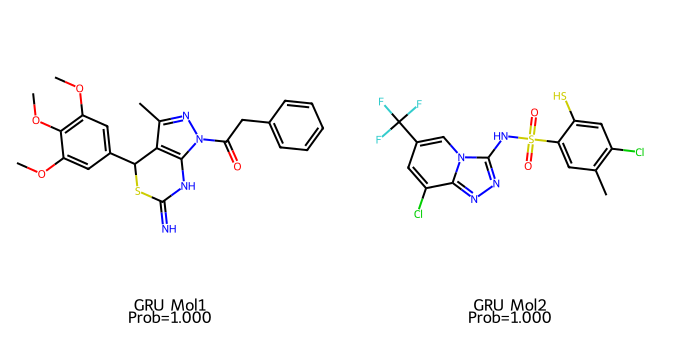

In [13]:
# ================================
# GRU FINAL PIPELINE (FULL SMILES FIX)
# ================================

import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, train_test_split
from tensorflow.keras.callbacks import EarlyStopping

# 🔴 SMILES kesilmesini engelle
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# 1) Select the best fold
auc_col = "test_roc_auc" if "test_roc_auc" in results_df.columns else results_df.columns[-2]
best_fold_idx = int(results_df[auc_col].astype(float).idxmax())
best_fold_number = best_fold_idx + 1
print(f"Using fold column: {auc_col}")
print(f"Using best fold: {best_fold_number}")

# 2) Rebuild the same fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
X_index = np.arange(len(df))
y_all = df["HIV_active"].values

splits = list(skf.split(X_index, y_all))
train_idx, temp_idx = splits[best_fold_idx]

train_df = df.iloc[train_idx].reset_index(drop=True)
temp_df = df.iloc[temp_idx].reset_index(drop=True)

val_idx, test_idx = train_test_split(
    np.arange(len(temp_df)),
    test_size=0.5,
    random_state=SEED + best_fold_number,
    stratify=temp_df["HIV_active"]
)

val_df = temp_df.iloc[val_idx].reset_index(drop=True)
test_df = temp_df.iloc[test_idx].reset_index(drop=True)

# 3) Same encoding
X_train = encode_smiles(train_df["smiles"])
X_val   = encode_smiles(val_df["smiles"])
X_test  = encode_smiles(test_df["smiles"])

y_train = train_df["HIV_active"].astype(np.float32).values
y_val   = val_df["HIV_active"].astype(np.float32).values
y_test  = test_df["HIV_active"].astype(np.float32).values
smiles_test = test_df["smiles"].reset_index(drop=True)

# 4) Rebuild and train the model
set_seed(SEED + best_fold_number)

model = build_gru_model()

early_stop = EarlyStopping(
    monitor="val_auc",
    mode="max",
    patience=PATIENCE,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    shuffle=True,
    verbose=0
)

# 5) Find the best threshold using validation
val_probs = model.predict(X_val, verbose=0).ravel()
best_threshold, best_val_f1 = find_best_threshold_by_f1(y_val, val_probs)

# 6) Test tahmini
y_prob = model.predict(X_test, verbose=0).ravel()
y_pred = (y_prob >= best_threshold).astype(int)

df_pred = pd.DataFrame({
    "fold": best_fold_number,
    "smiles": smiles_test,
    "y_true": y_test,
    "y_pred": y_pred,
    "y_prob": y_prob
})

# 7) Top 10 candidates
top_df = df_pred.sort_values(by="y_prob", ascending=False).head(10).reset_index(drop=True)

# 8) Descriptor hesaplama
def compute_desc(sm):
    mol = Chem.MolFromSmiles(sm)
    if mol is None:
        return None

    mw = Descriptors.MolWt(mol)
    logp = Crippen.MolLogP(mol)
    hbd = RdLipinski.NumHDonors(mol)
    hba = RdLipinski.NumHAcceptors(mol)
    tpsa = Descriptors.TPSA(mol)
    rot = RdLipinski.NumRotatableBonds(mol)
    qed = QED.qed(mol)
    lip = (mw <= 500) and (logp <= 5) and (hbd <= 5) and (hba <= 10)

    return {
        "MW": mw,
        "LogP": logp,
        "HBD": hbd,
        "HBA": hba,
        "TPSA": tpsa,
        "RotatableBonds": rot,
        "QED": qed,
        "Lipinski": lip
    }

rows = []
for _, row in top_df.iterrows():
    d = compute_desc(row["smiles"])
    if d is not None:
        d.update(row.to_dict())
        rows.append(d)

df_desc = pd.DataFrame(rows)

# 9) Shared column order
df_desc = df_desc[[
    "MW", "LogP", "HBD", "HBA", "TPSA", "RotatableBonds",
    "QED", "smiles", "fold", "y_true", "y_pred", "y_prob", "Lipinski"
]]

print("\nGRU TOP 10 CANDIDATES:")
display(df_desc)

# 🔥 FULL SMILES (TOP 10)
print("\nFULL SMILES (TOP 10):")
for i, smi in enumerate(df_desc["smiles"], start=1):
    print(f"{i}. {smi}")

# 10) Final 2 candidates
filtered_df = df_desc[df_desc["Lipinski"] == True].copy()

if len(filtered_df) >= 2:
    final_df = filtered_df.sort_values(by=["QED", "y_prob"], ascending=False).head(2).copy()
else:
    final_df = df_desc.sort_values(by=["QED", "y_prob"], ascending=False).head(2).copy()

final_df = final_df[[
    "MW", "LogP", "HBD", "HBA", "TPSA", "RotatableBonds",
    "QED", "smiles", "fold", "y_true", "y_pred", "y_prob", "Lipinski"
]]

print("\nGRU FINAL 2 CANDIDATES:")
display(final_df)

# 🔥 FULL SMILES (FINAL 2)
print("\nFULL SMILES (FINAL 2):")
for i, smi in enumerate(final_df["smiles"], start=1):
    print(f"{i}. {smi}")

# 11) Save
df_desc.to_csv("GRU_top_10_candidates.csv", index=False)
final_df.to_csv("GRU_final_2_candidates.csv", index=False)
final_df["smiles"].to_csv("GRU_docking_input.smi", index=False, header=False)

print("\nSaved: GRU_top_10_candidates.csv")
print("Saved: GRU_final_2_candidates.csv")
print("Saved: GRU_docking_input.smi")

# 12) Colored drawing
mols = [Chem.MolFromSmiles(sm) for sm in final_df["smiles"]]

img = Draw.MolsToGridImage(
    mols,
    molsPerRow=2,
    subImgSize=(340, 340),
    legends=[
        f"GRU Mol1\nProb={final_df.iloc[0]['y_prob']:.3f}" if len(final_df) > 0 else "",
        f"GRU Mol2\nProb={final_df.iloc[1]['y_prob']:.3f}" if len(final_df) > 1 else ""
    ]
)

display(img)